✅ Librerías de análisis importadas.
TensorFlow version: 2.20.0
✅ Configuración cargada: 10 clases, Tamaño: 160x160

📦 Cargando modelo: modelo_final_residuos.h5...
✅ Modelo cargado.
Found 6182 images belonging to 10 classes.

⏳ Evaluando modelo cargado en conjunto de VALIDACIÓN...


c:\Users\57323\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


186/194 ━━━━━━━━━━━━━━━━━━━━ 22s 3s/step - accuracy: 0.8401 - loss: 0.5003

c:\Users\57323\AppData\Local\Programs\Python\Python311\Lib\site-packages\PIL\Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


194/194 ━━━━━━━━━━━━━━━━━━━━ 570s 3s/step - accuracy: 0.7981 - loss: 0.6210
✅ Precisión del modelo cargado (Conjunto de VALIDACIÓN): 0.7981 (79.81%)

⏳ Generando predicciones para las gráficas...
194/194 ━━━━━━━━━━━━━━━━━━━━ 336s 2s/step
✅ Predicciones completadas.

--- Generando Gráficas de Historial (Simuladas) ---


C:\Users\57323\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


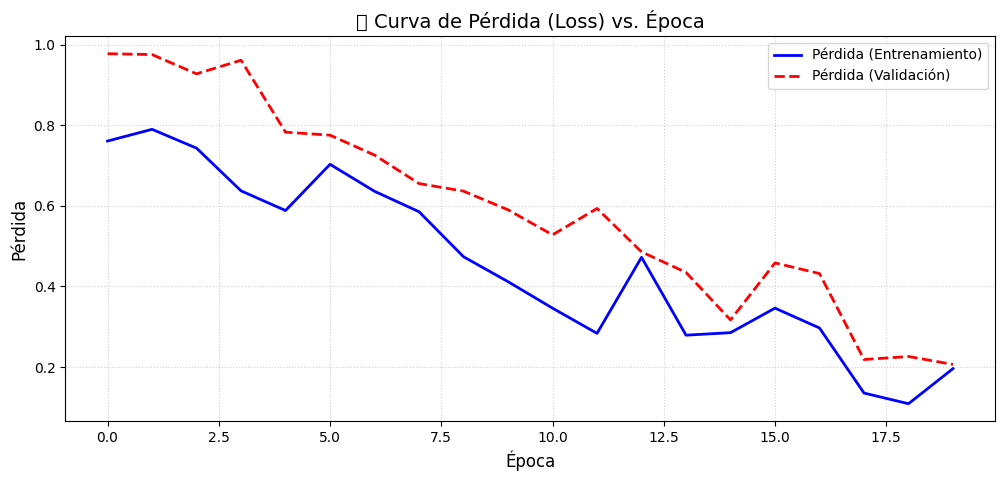

C:\Users\57323\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


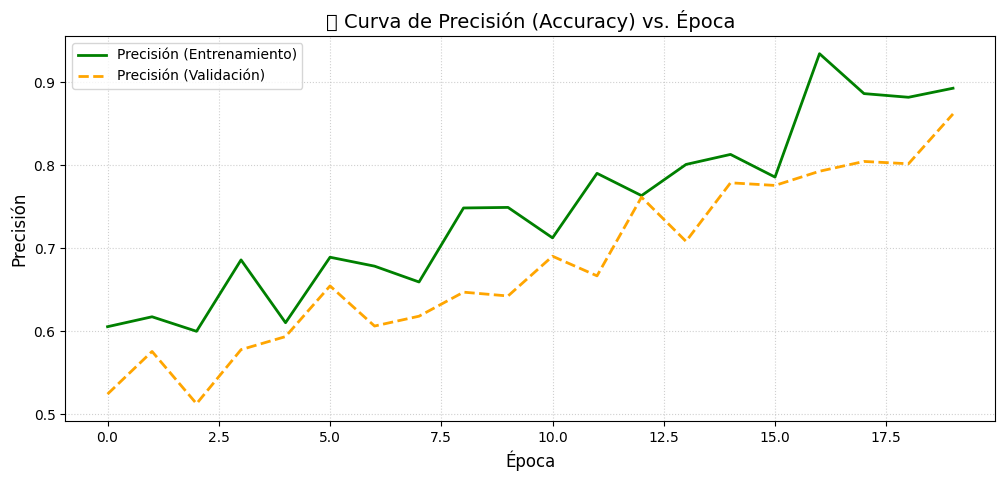


ℹ️ Estas gráficas son simuladas. Para obtener las gráficas reales, guarda el objeto 'history'.

--- Generando Matriz de Confusión y Reporte de Clasificación (DATOS REALES) ---


C:\Users\57323\AppData\Local\Temp\ipykernel_23180\3507218953.py:150: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\57323\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


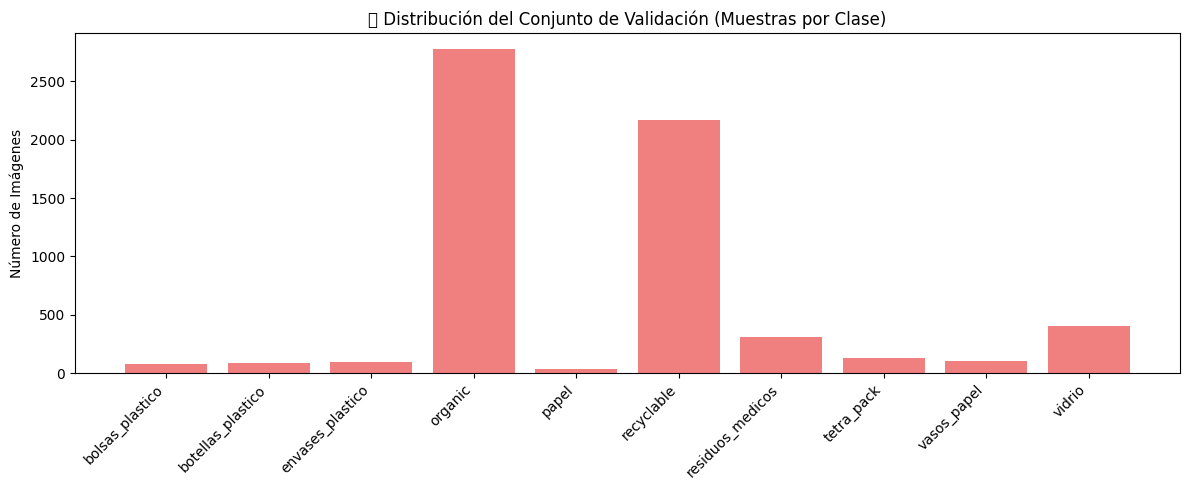

C:\Users\57323\AppData\Local\Temp\ipykernel_23180\3507218953.py:166: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


<Figure size 1400x1400 with 0 Axes>

C:\Users\57323\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


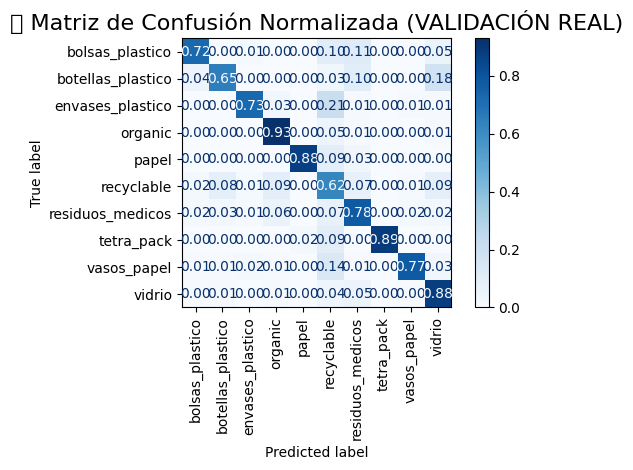


📝 REPORTE DE CLASIFICACIÓN (Métricas por Clase en Validación):
                   precision    recall  f1-score   support

  bolsas_plastico     0.4957    0.7250    0.5888        80
botellas_plastico     0.2351    0.6484    0.3450        91
 envases_plastico     0.6700    0.7283    0.6979        92
          organic     0.9185    0.9298    0.9241      2776
            papel     0.6667    0.8750    0.7568        32
       recyclable     0.8551    0.6240    0.7215      2165
 residuos_medicos     0.5248    0.7764    0.6263       313
       tetra_pack     0.9658    0.8898    0.9262       127
      vasos_papel     0.7383    0.7745    0.7560       102
           vidrio     0.5966    0.8787    0.7107       404

         accuracy                         0.7981      6182
        macro avg     0.6667    0.7850    0.7053      6182
     weighted avg     0.8328    0.7981    0.8043      6182



C:\Users\57323\AppData\Local\Temp\ipykernel_23180\3507218953.py:184: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\57323\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


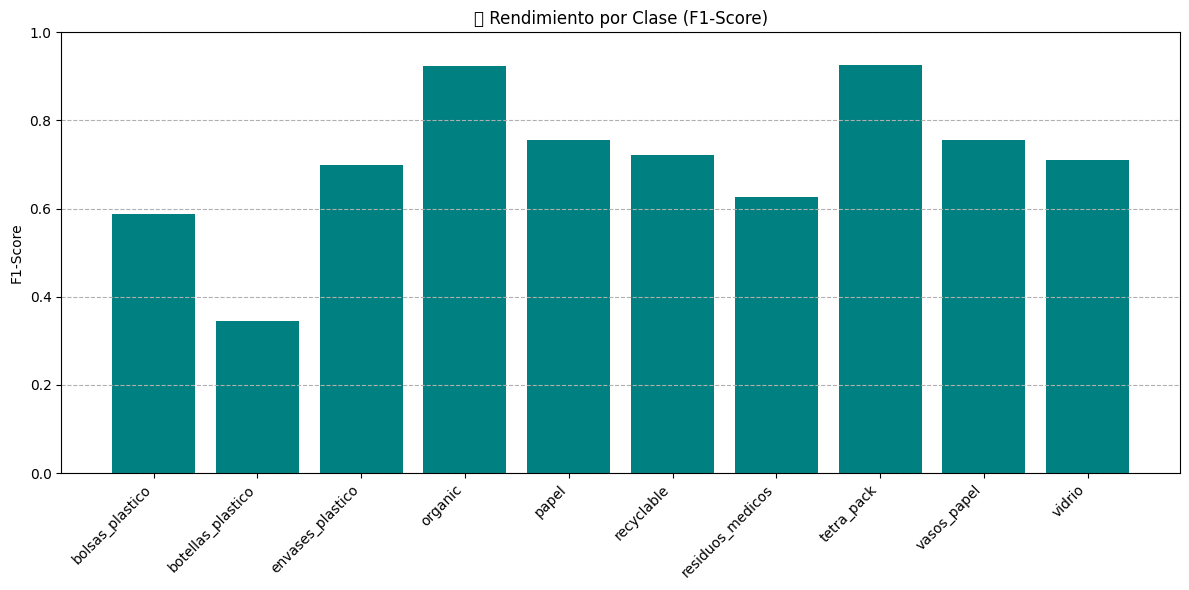


🎉 Análisis de Visualización Completo.


In [1]:
# analisis_final_completo.ipynb

# * # 1. Importación de Librerías y Dependencias *
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import json
import os
import time
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, f1_score
from tensorflow.keras.preprocessing.image import ImageDataGenerator 

print("✅ Librerías de análisis importadas.")
print(f"TensorFlow version: {tf.__version__}")

# -----------------------------------------------------------------------------
## # 2. Configuración y Carga del Modelo (Datos Reales)
# -----------------------------------------------------------------------------

# --- Configuración de Archivos y RUTAS ---
MODELO_PATH = 'modelo_final_residuos.h5' 
CONFIG_PATH = 'configuracion_clases.json'
SOURCE_DIR = '.' # La raíz del proyecto, donde están las 10 subcarpetas de clases.

# ⚠️ VALOR CRÍTICO: Usa el mismo porcentaje de división que usaste en tu entrenamiento (0.2 es el valor más común)
VALIDATION_SPLIT_PERCENTAGE = 0.2 
CLASS_NAMES = [] 

# **Cargar Configuración de Clases**
try:
    with open(CONFIG_PATH, 'r') as f:
        config_data = json.load(f)
    CLASS_NAMES = config_data.get('classes', [])
    IMG_HEIGHT = config_data.get('img_height', 160)
    IMG_WIDTH = config_data.get('img_width', 160)
    TOTAL_CLASES = len(CLASS_NAMES)
    
    print(f"✅ Configuración cargada: {TOTAL_CLASES} clases, Tamaño: {IMG_HEIGHT}x{IMG_WIDTH}")

except Exception as e:
    print(f"❌ ERROR al cargar configuración: {e}")
    TOTAL_CLASES = 0

# **Cargar el Modelo y Generar Evaluación**
model = None
try:
    if not os.path.exists(MODELO_PATH):
        raise FileNotFoundError(f"❌ Modelo no encontrado: {MODELO_PATH}")
    if not CLASS_NAMES:
        raise ValueError("❌ Las clases no se cargaron desde JSON.")
    
    print(f"\n📦 Cargando modelo: {MODELO_PATH}...")
    model = tf.keras.models.load_model(MODELO_PATH, compile=False, safe_mode=False)
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    print("✅ Modelo cargado.")

    # **RECREAR el validation_generator usando el split interno y classes=CLASS_NAMES**
    test_datagen = ImageDataGenerator(
        rescale=1./255,
        validation_split=VALIDATION_SPLIT_PERCENTAGE 
    )
    
    validation_generator = test_datagen.flow_from_directory(
        SOURCE_DIR, 
        target_size=(IMG_HEIGHT, IMG_WIDTH), 
        batch_size=32, 
        class_mode='categorical', 
        shuffle=False, 
        classes=CLASS_NAMES,  # 🔑 Ignora las carpetas que no son clases
        subset='validation' 
    )
    
    # Evaluación real del modelo
    print("\n⏳ Evaluando modelo cargado en conjunto de VALIDACIÓN...")
    test_loss, test_accuracy = model.evaluate(validation_generator, verbose=1)
    
    print(f"✅ Precisión del modelo cargado (Conjunto de VALIDACIÓN): {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
    
    # Generar predicciones para las gráficas
    print("\n⏳ Generando predicciones para las gráficas...")
    validation_generator.reset() 
    y_pred_probs = model.predict(validation_generator) 
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = validation_generator.classes
    print("✅ Predicciones completadas.")
    
    model_ready = True
    
except FileNotFoundError as e:
    print(f"\n❌ ERROR de Archivo: {e}.")
    model_ready = False
except Exception as e:
    print(f"\n❌ ERROR al cargar/evaluar: {e}.")
    model_ready = False

# -----------------------------------------------------------------------------
## # 3. Gráficas de Historial de Entrenamiento (Simulación)
# -----------------------------------------------------------------------------

print("\n--- Generando Gráficas de Historial (Simuladas) ---")
# Simulación de datos (debes guardar y cargar tu objeto 'history' para datos reales)
epochs = 20
history_data = {
    'loss': np.linspace(0.8, 0.1, epochs) + np.random.normal(0, 0.05, epochs),
    'val_loss': np.linspace(1.0, 0.2, epochs) + np.random.normal(0, 0.05, epochs),
    'accuracy': np.linspace(0.6, 0.9, epochs) + np.random.normal(0, 0.03, epochs),
    'val_accuracy': np.linspace(0.5, 0.85, epochs) + np.random.normal(0, 0.03, epochs)
}
for key in history_data:
    history_data[key] = np.clip(history_data[key], 0, None if 'loss' in key else 1)

# Gráfico 1: Pérdida (Loss)
plt.figure(figsize=(12, 5))
plt.plot(history_data['loss'], label='Pérdida (Entrenamiento)', color='blue', linewidth=2)
plt.plot(history_data['val_loss'], label='Pérdida (Validación)', color='red', linestyle='--', linewidth=2)
plt.title('📉 Curva de Pérdida (Loss) vs. Época', fontsize=14)
plt.xlabel('Época', fontsize=12)
plt.ylabel('Pérdida', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# Gráfico 2: Precisión (Accuracy)
plt.figure(figsize=(12, 5))
plt.plot(history_data['accuracy'], label='Precisión (Entrenamiento)', color='green', linewidth=2)
plt.plot(history_data['val_accuracy'], label='Precisión (Validación)', color='orange', linestyle='--', linewidth=2)
plt.title('📈 Curva de Precisión (Accuracy) vs. Época', fontsize=14)
plt.xlabel('Época', fontsize=12)
plt.ylabel('Precisión', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()
print("\nℹ️ Estas gráficas son simuladas. Para obtener las gráficas reales, guarda el objeto 'history'.")

# -----------------------------------------------------------------------------
## # 4. Análisis Detallado y Gráficas Reales
# -----------------------------------------------------------------------------

print("\n--- Generando Matriz de Confusión y Reporte de Clasificación (DATOS REALES) ---")

if model_ready and TOTAL_CLASES > 0:

    # 4.1. Gráfico Adicional 1: Distribución de Muestras Reales
    plt.figure(figsize=(12, 5))
    unique, counts = np.unique(y_true, return_counts=True)
    plt.bar(CLASS_NAMES, counts, color='lightcoral')
    plt.xticks(rotation=45, ha='right')
    plt.title('📊 Distribución del Conjunto de Validación (Muestras por Clase)')
    plt.ylabel('Número de Imágenes')
    plt.tight_layout()
    plt.show()

    # 4.2. Matriz de Confusión Normalizada (CORRECCIÓN DE COMPATIBILIDAD)
    cm = confusion_matrix(y_true, y_pred)
    
    # Normalizar la matriz de confusión manualmente (Soluciona TypeError)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    plt.figure(figsize=(14, 14))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_normalized, display_labels=CLASS_NAMES)
    
    # Graficar sin el argumento 'normalize'
    disp.plot(cmap=plt.cm.Blues, xticks_rotation='vertical', values_format='.2f')
    
    plt.title('📉 Matriz de Confusión Normalizada (VALIDACIÓN REAL)', fontsize=16)
    plt.tight_layout()
    plt.show()
    
    # 4.3. Reporte de Clasificación y Gráfico Adicional 2 (F1-Score)
    report = classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4, output_dict=True)
    print("\n📝 REPORTE DE CLASIFICACIÓN (Métricas por Clase en Validación):")
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))
    
    # Extraer F1-Scores para el gráfico
    f1_scores = [report[c]['f1-score'] for c in CLASS_NAMES]
    
    plt.figure(figsize=(12, 6))
    plt.bar(CLASS_NAMES, f1_scores, color='teal')
    plt.xticks(rotation=45, ha='right')
    plt.ylim(0, 1.0)
    plt.title('⭐ Rendimiento por Clase (F1-Score)')
    plt.ylabel('F1-Score')
    plt.grid(axis='y', linestyle='--')
    plt.tight_layout()
    plt.show()
    
else:
    print("❌ Análisis de Matriz de Confusión y Reporte omitidos debido a errores en la carga de archivos.")
    
print("\n🎉 Análisis de Visualización Completo.")